In [1]:
import numpy as np
#import ray
import matplotlib.pyplot as plt
import pythtb
import wannierberri as wberri
from wannierberri.system import System_PythTB
from pythtb import tb_model
from wannierberri.evaluate_k import evaluate_k_path
from hall_ps.hall_positional_shift import HallPositionalShift
_=wberri.welcome()


.::    .   .::: .:::::::.  :::.    :::.:::.    :::. :::.,::::::  :::::::..       :::::::.  .,::::::  :::::::..   :::::::..   :::
';;,  ;;  ;;;' '  ;;`;;  ` `;;;;,  `;;;`;;;;,  `;;; ;;;;;;;''''  ;;;;``;;;;       ;;;'';;' ;;;;''''  ;;;;``;;;;  ;;;;``;;;;  ;;;
 '[[, [[, [['    ,[[ '[[,    [[[[[. '[[  [[[[[. '[[ [[[ [[cccc    [[[,/[[['       [[[__[[\. [[cccc    [[[,/[[['   [[[,/[[['  [[[
   Y$c$$$c$P    c$$$cc$$$c   $$$ "Y$c$$  $$$ "Y$c$$ $$$ $$""""    $$$$$$c         $$""""Y$$ $$""""    $$$$$$c     $$$$$$c    $$$
    "88"888      888   888,  888    Y88  888    Y88 888 888oo,__  888b "88bo,    _88o,,od8P 888oo,__  888b "88bo, 888b "88bo,888
     "M "M"      YMM   ""`   MMM     YM  MMM     YM MMM """"YUMMM MMMM   "W"     ""YUMMMP"  """"YUMMM MMMM   "W"  MMMM   "W" MMM

Version: 26.4.5.dev1+gd4c245e3e.d20260409


   HTTP://WANNIER-BERRI.ORG  

Checking dependencies …
irrep : 2.6.3
spglib : 2.7.0
numpy : 2.4.2
scipy : 1.15.2
spgrep : 0.5.0
numba : 0.64.0
pyfftw : 0.15.1
seekpath : 2.2.1
matp

# WannierBerri PythTB

In [2]:
def model_ferroaxial_pythtb(mu=0.0, t=1.0, tp=1.0, Delta=1.0, t2=0.5, t3=1.0, a=1.0, c=1.0):

    a_latt = a*np.sqrt(3)
    lat = np.array([[a_latt,-0,0], [-a_latt/2, a_latt*np.sqrt(3)/2, 0], [0, 0, c]])
    orb = np.array([[0, 0, 0] , [1/3, 2/3, 0]])  
    
    #lattice = pythtb.Lattice(lat_vecs=lat, orb_vecs=orb, periodic_dirs=[0, 1, 2])
    #my_model = pythtb.TBModel(lattice)

    my_model = tb_model(3, 3, lat, orb)
    my_model.set_onsite([Delta - mu, -Delta - mu])

    
    for shift in [[0,0,0], [0, -1,0], [-1,-1,0]]:
        # nearest neighbor hoppings in-plane (t)
        my_model.set_hop(t, 0, 1, shift)
        # Vertical Hoppings (tpz)
        if tp != 0:
            for z in [1, -1]:
                my_model.set_hop( tp, 0, 1, [shift[0], shift[1],  z])


    if t3 != 0:
        # Third Neighbor Hoppings (tp)
        my_model.set_hop( t3, 1, 0, [ 2,  2,  0]) 
        my_model.set_hop( t3, 1, 0, [ 0, -1,  0])
        my_model.set_hop( t3, 1, 0, [-1,  1,  0])
        my_model.set_hop(-t3, 0, 1, [ 1,  1,  0]) 
        my_model.set_hop(-t3, 0, 1, [-2, -1,  0])
        my_model.set_hop(-t3, 0, 1, [ 0, -2,  0])


    # The tc term (Diagonal Hoppings)
    if t2 != 0:
        for shift in [[0,1,0], [1,0,0], [1,1,0]]: # Skipping [0,0,0] for diagonal
            for i in range(2):
                my_model.set_hop(t2, i, i, shift)

    return my_model

# k-resolved

In [3]:
from wannierberri.formula.covariant import QuantumMetric_ab
from wannierberri.formula.covariant import DerQuantumMetric_ab_d
from hall_ps.hall_positional_shift import HallPositionalShift, PositionalShiftFormula

Efermi = np.linspace(-10, +10, 1601)

def plot_k_resolved( parameters_model, k_nodes, k_labels):
    model = model_ferroaxial_pythtb(**parameters_model)
    system = System_PythTB(model)
    
    path = wberri.Path.from_nodes(system,
        nodes=k_nodes,
        labels=k_labels,
        nk=200
    )  

    tabulator =wberri.calculators.TabulatorAll(
        {
            "energy": wberri.calculators.tabulate.Energy(),
            "g": wberri.calculators.tabulate.Tabulator(Formula=QuantumMetric_ab),
            "dg_dk": wberri.calculators.tabulate.Tabulator(Formula=DerQuantumMetric_ab_d),
            "pos_shift_morb": wberri.calculators.tabulate.Tabulator(Formula=PositionalShiftFormula, 
                                                                    kwargs_formula={"morb_part": True, 
                                                                                "metric_part":False},
                                                                                ),
            "pos_shift_metric": wberri.calculators.tabulate.Tabulator(Formula=PositionalShiftFormula, 
                                                                    kwargs_formula={"morb_part": False,
                                                                                "metric_part":True},),
            "Omega" : wberri.calculators.tabulate.BerryCurvature(),
            'pos_shift_calc' : HallPositionalShift(Efermi=Efermi, k_resolved=True, kwargs_formula={"morb_part": True, "external_terms": False})

        },
        mode="path"
    )
    
    result = wberri.run(
        system=system,
        grid=path,
        calculators={"tab": tabulator},
    )
    res_tab = result.results["tab"]
    energy = res_tab.get_data("energy")   
    print ("Energy shape:", energy.shape)
    g = res_tab.get_data("g")         
    print ("g shape:", g.shape)
    dg_dk = res_tab.get_data("dg_dk") 
    print ("dg_dk shape:", dg_dk.shape)
    pos_shift_morb = res_tab.get_data("pos_shift_morb")  
    print ("pos_shift_morb shape:", pos_shift_morb.shape)
    pos_shift_metric = res_tab.get_data("pos_shift_metric") 
    print ("pos_shift_metric shape:", pos_shift_metric.shape)
    Omega = res_tab.get_data("Omega")        
    print ("Omega shape:", Omega.shape)
    pos_shift_calc = res_tab.results["pos_shift_calc"].data
    print ("pos_shift_calc shape:", pos_shift_calc.shape)

    kline = path.getKline()
    x_ticks_labels = []
    x_ticks_positions = []
    for k, v in path.labels.items():
        x_ticks_labels.append(v)
        x_ticks_positions.append(kline[k])

    def make_subplot(axes, data_dict, ylabel, title):
        for k,v in data_dict.items():
            axes.plot(kline, v[:,0], label=f"Band 1, {k}")
            axes.plot(kline, v[:,1], label=f"Band 2, {k}", linestyle='--')
        axes.set_ylabel(ylabel)
        axes.set_title(title)
        axes.set_xticks(ticks=x_ticks_positions)
        axes.set_xticklabels(labels=x_ticks_labels)
        axes.grid(True, which='both', linestyle='--', linewidth=0.5)
        axes.legend()

    fig, axes = plt.subplots(1, 3, figsize=(12, 5))
    make_subplot(axes[0], {"": energy}, "Energy (eV)", "Band Structure")
    make_subplot(axes[1], {r"$F_{xz}^O$": pos_shift_morb[:, :, 0, 2], 
                            r"$F_{yz}^O$": pos_shift_morb[:, :, 1, 2]}, 
                            r"$\AA^3$" , "Positional Shift (Morb Part)")
    make_subplot(axes[2], {r"$F_{xz}^G$": pos_shift_metric[:, :, 0, 2], 
                            r"$F_{yz}^G$": pos_shift_metric[:, :, 1, 2]}, 
                            r"$\AA^3$" , "Positional Shift (Metric Part)")
    # parameters in the figure title
    title = ", ".join([f"{k}={v}" for k, v in sorted(parameters_model.items())])
    filename="_".join([f"{k}={v}" for k, v in sorted(parameters_model.items())])
    fig.suptitle("Ferroaxial TB Model: " + title, fontsize=20)
    fig.savefig(f"ferroaxial_tb_{filename}.pdf")
    plt.tight_layout()
    fig.show()




        


Reading the system from PythTB model. Needed data: {'Ham'}
number of wannier functions: 2
shape of Ham_R = (23, 2, 2)
Real-space lattice:
 [[ 1.73205081  0.          0.        ]
 [-0.8660254   1.5         0.        ]
 [ 0.          0.          1.        ]]
Number of wannier functions: 2
Number of R points: 23
Recommended size of FFT grid [5 5 3]
Reading the system from PythTB finished successfully


/tmp/ipykernel_116705/1596711675.py:10: DeprecationWarning: pythtb.tb_model is deprecated and will be removed in a future release. Use TBModel instead.
  my_model = tb_model(3, 3, lat, orb)
/home/stepan/github/wannier-berri/.conda/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-04-09 18:31:52,732	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


Starting run()
Using the follwing calculators : 
############################################################

 'tab'  :  <wannierberri.calculators.tabulate.TabulatorAll object at 0x7a0f81959250>  : 
    TabulatorAll - a pack of all k-resolved calculators (Tabulators)
    
 Includes the following tabulators : 
--------------------------------------------------
 "energy" : <wannierberri.calculators.tabulate.Energy object at 0x7a0f81f89460> : calculator not described

 "g" : <wannierberri.calculators.tabulate.Tabulator object at 0x7a0f81a5d790> : calculator not described

 "dg_dk" : <wannierberri.calculators.tabulate.Tabulator object at 0x7a0f818a7800> : calculator not described

 "pos_shift_morb" : <wannierberri.calculators.tabulate.Tabulator object at 0x7a0f81a2a690> : calculator not described

 "pos_shift_metric" : <wannierberri.calculators.tabulate.Tabulator object at 0x7a0f82853800> : calculator not described

 "Omega" : <wannierberri.calculators.tabulate.BerryCurvature object at 0x

/home/stepan/github/wannier-berri/wannierberri/parallel.py:121: UserWarning: ray package found, but ray is not initialized, running in serial mode
  warnings.warn("ray package found, but ray is not initialized, running in serial mode")
/home/stepan/github/wannier-berri/wannierberri/grid/path.py:272: UserWarning: symmetry is not used for a tabulation along path
  warnings.warn("symmetry is not used for a tabulation along path")


time for processing    996 K-points on   1 processes:     3.4431 ; per K-point          0.0035 ; proc-sec per K-point          0.0035
time1 =  4.76837158203125e-07
Totally processed 996 K-points 
run() finished
Energy shape: (996, 2)
g shape: (996, 2, 3, 3)
dg_dk shape: (996, 2, 3, 3, 3)
pos_shift_morb shape: (996, 2, 3, 3)
pos_shift_metric shape: (996, 2, 3, 3)
Omega shape: (996, 2, 3)
pos_shift_calc shape: (996, 1601, 3, 3)
Reading the system from PythTB model. Needed data: {'Ham'}
number of wannier functions: 2
shape of Ham_R = (25, 2, 2)
Real-space lattice:
 [[ 1.73205081  0.          0.        ]
 [-0.8660254   1.5         0.        ]
 [ 0.          0.          1.        ]]
Number of wannier functions: 2
Number of R points: 25
Recommended size of FFT grid [5 5 3]
Reading the system from PythTB finished successfully
Starting run()
Using the follwing calculators : 
############################################################

 'tab'  :  <wannierberri.calculators.tabulate.TabulatorAll

/tmp/ipykernel_116705/4267707112.py:89: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/tmp/ipykernel_116705/1596711675.py:10: DeprecationWarning: pythtb.tb_model is deprecated and will be removed in a future release. Use TBModel instead.
  my_model = tb_model(3, 3, lat, orb)
/home/stepan/github/wannier-berri/wannierberri/parallel.py:121: UserWarning: ray package found, but ray is not initialized, running in serial mode
  warnings.warn("ray package found, but ray is not initialized, running in serial mode")
/home/stepan/github/wannier-berri/wannierberri/grid/path.py:272: UserWarning: symmetry is not used for a tabulation along path
  warnings.warn("symmetry is not used for a tabulation along path")


time for processing    996 K-points on   1 processes:     3.4755 ; per K-point          0.0035 ; proc-sec per K-point          0.0035
time1 =  4.76837158203125e-07
Totally processed 996 K-points 
run() finished
Energy shape: (996, 2)
g shape: (996, 2, 3, 3)
dg_dk shape: (996, 2, 3, 3, 3)
pos_shift_morb shape: (996, 2, 3, 3)
pos_shift_metric shape: (996, 2, 3, 3)
Omega shape: (996, 2, 3)
pos_shift_calc shape: (996, 1601, 3, 3)


/tmp/ipykernel_116705/4267707112.py:89: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


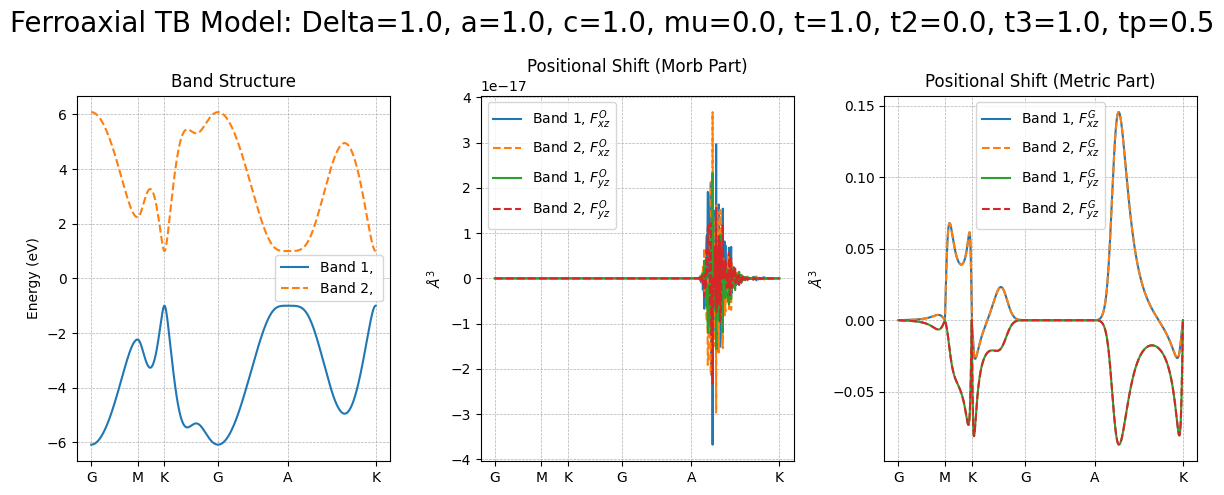

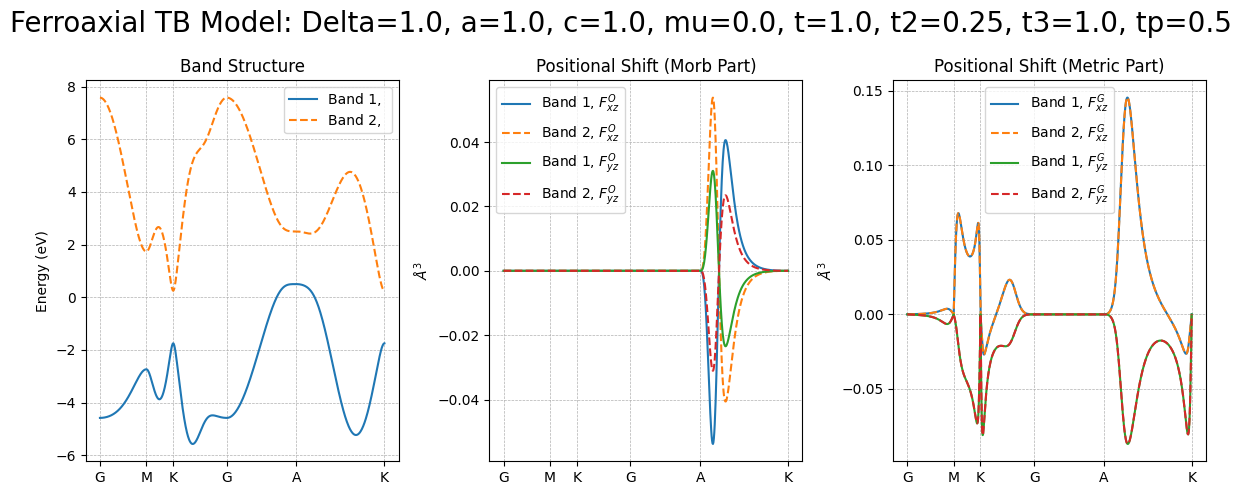

In [4]:
nodes=[
        [0.0, 0.0, 0.0],  # G (Gamma): Center of the BZ
        [0.5, 0.0, 0.0],  # M: Center of the rectangular side face
        [1/3, 1/3, 0.0],   # K: Corner of the hexagonal face
        [0.0, 0.0, 0.0],  # G (Gamma): Center of the BZ
        [0.0, 0.0, 0.5],  # A: Center of the top face (k_z = pi/c)
        [1/3, 1/3, 0.0]   # K: Corner of the hexagonal face
    ]
labels=["G", "M", "K", "G", "A", "K"]

parameters1 = dict(mu=0.0, t=1.0, tp=0.5, Delta=1.0, t3=1.0, t2=0.0, a=1.0, c=1.0)
plot_k_resolved(parameters1, k_nodes=nodes, k_labels=labels)
parameters2 = dict(mu=0.0, t=1.0, tp=0.5, Delta=1.0, t3=1.0, t2=0.25, a=1.0, c=1.0)
plot_k_resolved(parameters2, k_nodes=nodes, k_labels=labels)